In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [5]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 8s 1us/step


In [6]:
x_train = x_train/255.0
x_test = x_test/255.0


In [7]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [10]:
model = Sequential(
    [
        Flatten(input_shape = (28,28)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax') ]
)

In [11]:
model.compile(
    optimizer='adam',
    loss= 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [13]:
history = model.fit(

    x_train, y_train,
    epochs = 10,
    batch_size = 32,
    validation_split = 0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9252 - loss: 0.2562 - val_accuracy: 0.9623 - val_loss: 0.1220
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9673 - loss: 0.1070 - val_accuracy: 0.9708 - val_loss: 0.0977
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9759 - loss: 0.0753 - val_accuracy: 0.9740 - val_loss: 0.0915
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9821 - loss: 0.0566 - val_accuracy: 0.9745 - val_loss: 0.0938
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9857 - loss: 0.0435 - val_accuracy: 0.9785 - val_loss: 0.0841
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9878 - loss: 0.0379 - val_accuracy: 0.9758 - val_loss: 0.0864
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9900 - loss: 0.0293 - val_accuracy: 0.9810 - val_loss: 0.0720
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9916 - loss: 0.0251 -

In [14]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step - accuracy: 0.9771 - loss: 0.0957
Test accuracy: 0.9771000146865845


In [15]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

In [48]:
img = Image.open("img1.png").convert("L")
img = ImageOps.invert(img)
img = img.resize((28,28))

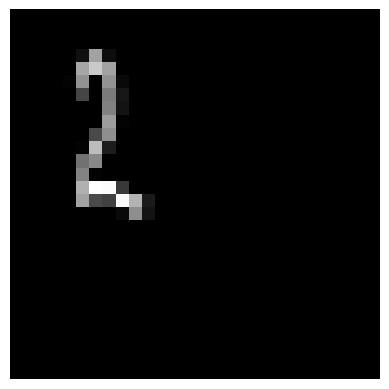

In [49]:
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.show()

In [50]:
img_array = np.array(img) / 255.0
img_array = img_array.reshape(1, 28, 28)

In [51]:
prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [52]:
digit  = np.argmax(prediction)
print(f"Predicted digit: {digit}")

Predicted digit: 5


In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
x_train = x_train/255.0
x_test = x_test/255.0

In [4]:
x_train = x_train .reshape(-1, 28,28,1)
x_test = x_test.reshape(-1, 28, 28, 1)


In [5]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [7]:
model = Sequential(
    [
        Conv2D(32, (3,3), activation = 'relu', input_shape = (28,28,1)),
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), activation = 'relu'),
        MaxPooling2D((2,2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')

    ]
)

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history= model.fit(
    x_train, y_train,
    epochs = 10,
    batch_size = 64,
    validation_split = 0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9146 - loss: 0.2818 - val_accuracy: 0.9842 - val_loss: 0.0529
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9717 - loss: 0.0951 - val_accuracy: 0.9882 - val_loss: 0.0403
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9783 - loss: 0.0711 - val_accuracy: 0.9897 - val_loss: 0.0367
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9826 - loss: 0.0580 - val_accuracy: 0.9913 - val_loss: 0.0371
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9853 - loss: 0.0492 - val_accuracy: 0.9922 - val_loss: 0.0309
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9871 - loss: 0.0419 - val_accuracy: 0.9905 - val_loss: 0.0343
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9891 - loss: 0.0359 - val_accuracy: 0.9922 - val_loss: 0.0303
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9907 - loss: 0.0302 - 

In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9921 - loss: 0.0245
Test accuracy: 0.9921000003814697


In [11]:
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

In [12]:
img = Image.open("img1.png").convert("L")
img = ImageOps.invert(img)
img = img.resize((28,28))

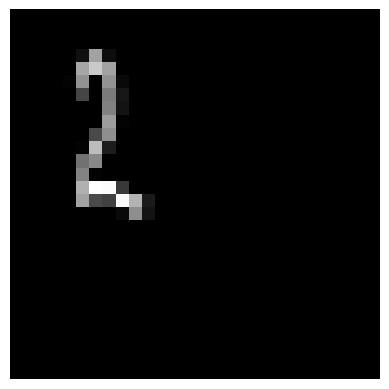

In [13]:
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.show()

In [15]:
img_array = np.array(img)/ 255.0
img_array = img_array.reshape(1, 28, 28, 1)

In [16]:
p = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


In [17]:
digit = np.argmax(p)
print("Predicted digit:", digit)

Predicted digit: 7


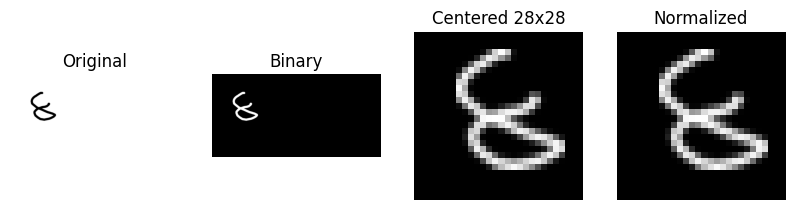

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Pred: 8 Probs: [0.    0.    0.    0.    0.    0.007 0.006 0.    0.987 0.   ]


In [25]:
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

def preprocess_digit_for_mnist(path, debug=True):
    # 1) Load & flatten transparency onto white
    img = Image.open(path)
    if img.mode == 'RGBA':
        bg = Image.new('RGBA', img.size, (255, 255, 255, 255))
        img = Image.alpha_composite(bg, img).convert('RGB')
    else:
        img = img.convert('RGB')

    # 2) To grayscale
    img = img.convert('L')  # 0=black, 255=white

    # 3) Auto invert if background is light (i.e., black digit on white)
    arr = np.array(img)
    bg_mean = arr.mean()
    if bg_mean > 127:  # likely white background
        arr = 255 - arr  # make digit white on black like MNIST

    # 4) Normalize to 0-1 for thresholding
    arr = arr.astype(np.uint8)

    # 5) Otsu threshold to get a clean binary mask
    # Simple Otsu implementation
    hist, bin_edges = np.histogram(arr, bins=256, range=(0,255))
    weight1 = np.cumsum(hist)
    weight2 = np.cumsum(hist[::-1])[::-1]
    mean1 = np.cumsum(hist*np.arange(256)) / np.maximum(weight1, 1)
    mean2 = (np.cumsum((hist*np.arange(256))[::-1]) / np.maximum(weight2[::-1],1))[::-1]
    variance12 = weight1[:-1] * weight2[1:] * (mean1[:-1] - mean2[1:])**2
    thresh = np.argmax(variance12)
    binary = (arr > thresh).astype(np.uint8) * 255  # 255 for digit (white), 0 for background

    # 6) Crop to bounding box
    coords = np.column_stack(np.where(binary > 0))
    if coords.size == 0:
        raise ValueError("No strokes found—check the image contrast.")
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    cropped = binary[y0:y1, x0:x1]

    # 7) Resize to 20x20 preserving aspect
    h, w = cropped.shape
    if h > w:
        new_h = 20
        new_w = max(1, int(round(w * (20 / h))))
    else:
        new_w = 20
        new_h = max(1, int(round(h * (20 / w))))
    resized = Image.fromarray(cropped).resize((new_w, new_h), Image.BILINEAR)

    # 8) Paste into 28x28 and center by center-of-mass
    canvas = Image.new('L', (28, 28), color=0)
    paste = np.array(resized)
    # initial paste roughly centered
    top = (28 - paste.shape[0]) // 2
    left = (28 - paste.shape[1]) // 2
    canvas_arr = np.array(canvas)
    canvas_arr[top:top+paste.shape[0], left:left+paste.shape[1]] = paste

    # center-of-mass shift
    yy, xx = np.mgrid[0:28, 0:28]
    m = canvas_arr / 255.0
    total = m.sum()
    if total > 0:
        cy = (yy*m).sum() / total
        cx = (xx*m).sum() / total
        shift_y = int(round(14 - cy))
        shift_x = int(round(14 - cx))
        shifted = np.roll(canvas_arr, shift=(shift_y, shift_x), axis=(0,1))
    else:
        shifted = canvas_arr

    # 9) Normalize to 0-1 and shape for CNN
    norm = shifted.astype(np.float32) / 255.0
    x = norm.reshape(1, 28, 28, 1)

    if debug:
        fig, axs = plt.subplots(1, 4, figsize=(10,3))
        axs[0].imshow(Image.open(path))
        axs[0].set_title('Original'); axs[0].axis('off')
        axs[1].imshow(binary, cmap='gray')
        axs[1].set_title('Binary'); axs[1].axis('off')
        axs[2].imshow(shifted, cmap='gray')
        axs[2].set_title('Centered 28x28'); axs[2].axis('off')
        axs[3].imshow(norm, cmap='gray')
        axs[3].set_title('Normalized'); axs[3].axis('off')
        plt.show()

    return x

# Usage:
x_input = preprocess_digit_for_mnist("img1.png", debug=True)
probs = model.predict(x_input)
print("Pred:", 
np.argmax(probs), "Probs:", np.round(probs[0], 3))
